start--->node1.strike rate 
     --->node2.Boundary Percentage
     --->node3.ball per boundary

     node4.Summary of all three nodes

     then end

input --> run , ball , 4s ,6s     

In [9]:
from langgraph.graph import StateGraph ,START ,END
from typing import  TypedDict


In [10]:
# state define
class batsman(TypedDict):
    runs:int
    ball:int
    fours:int
    sixes:int
    sr:float
    bpb:float
    boudary_percent:float
    summary:str

In [ ]:
# calculate_sr

def calculate_sr(state:batsman)->batsman:
    runs=state['runs']
    balls=state['ball']
    sr=(runs/balls)*100
    state['sr']=sr
    # return state   this iwll throw error as multiple state returns in parrallel way will confuse where to update what. instead we will send or return only the current updated or calculated value to the state
    return {"sr":sr}
def calculate_bpb(state:batsman)->batsman:
    balls=state['ball']
    fours=state['fours']
    sixes=state['sixes']
    bpb=balls/(fours+sixes)
    state['bpb']=bpb
    # return state
    return {"bpb":bpb}

def cal_boundaryPercent(state:batsman)->batsman:
    runs=state['runs']
    balls=state['ball']
    fours=state['fours']
    sixes=state['sixes']
    boudary_percent=((fours*4+sixes*6)/runs)*100
    state['boudary_percent']=boudary_percent
    # return state
    return {"boudary_percent":boudary_percent}

def summarizer(state:batsman)->batsman:
    summary=f"""
Strike rate:: {state['sr']} \n
Balls per Boundary:: {state['bpb']} \n
Boudary Percentage:: {state['boudary_percent']}
"""
    state['summary']=summary
    # return state
    return {"summary":summary}




In [12]:
# create graph
graph=StateGraph(batsman)
# add nodes
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("cal_boundaryPercent",cal_boundaryPercent)
graph.add_node("summarizer",summarizer)
# add edges
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"cal_boundaryPercent")

graph.add_edge("calculate_sr","summarizer")
graph.add_edge("calculate_bpb","summarizer")
graph.add_edge("cal_boundaryPercent","summarizer")

graph.add_edge("summarizer",END)



In [13]:
# compile graph
workflow=graph.compile()


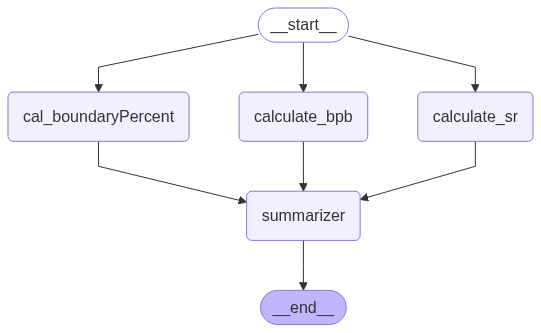

In [14]:
workflow

In [15]:
# invoke graph
intial_state={"runs":100,"ball":80,"fours":6,"sixes":6}
final_state=workflow.invoke(intial_state)

print(final_state)

{'runs': 100, 'ball': 80, 'fours': 6, 'sixes': 6, 'sr': 125.0, 'bpb': 6.666666666666667, 'boudary_percent': 60.0, 'summary': '\nStrike rate:: 125.0\n\nBalls per Boundary:: 6.666666666666667 \n\nBoudary Percentage:: 60.0\n'}


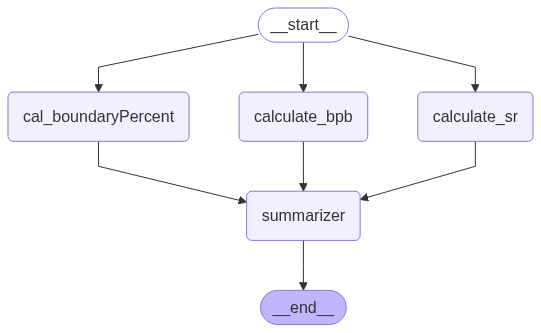

In [16]:
# how to see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())